In [1]:
!pip install https://github.com/poliastro/poliastro/archive/main.zip

     / 21.4 MB 14.2 MB/s 0:00:02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.8/994.8 kB 25.7 MB/s eta 0:00:00
  Created wheel for poliastro: filename=poliastro-0.18.dev0-py3-none-any.whl size=174971 sha256=44d52855717977db232a49622aba73c4482c4ee2fd7896747b083373051a714f
  Stored in directory: /tmp/pip-ephem-wheel-cache-um92x9pu/wheels/ba/44/b3/f87c7cb1986b1eb71653c6a3c65236e91002f061d3b948b773
Successfully built poliastro
  Attempting uninstall: astropy
    Found existing installation: astropy 7.0.0
    Uninstalling astropy-7.0.0:
      Successfully uninstalled astropy-7.0.0


In [2]:
from astropy import units as u
from astropy.time import Time
from matplotlib import pyplot as plt

# Now import modules from poliastro
from poliastro.bodies import Sun, Earth, Mars
from poliastro.ephem import Ephem
from poliastro.twobody import Orbit
from poliastro.util import time_range
from itertools import product
from poliastro.maneuver import Maneuver
from poliastro.plotting import OrbitPlotter

In [3]:
# Departure and time of flight for the mission
EPOCH_DPT = Time("2018-12-01", scale="tdb")
EPOCH_ARR = EPOCH_DPT + 2 * u.year

epochs = time_range(EPOCH_DPT, end=EPOCH_ARR)

# Origin and target orbits
earth = Ephem.from_body(Earth, epochs=epochs)
mars = Ephem.from_body(Mars, epochs=epochs)

earth_departure = Orbit.from_ephem(Sun, earth, EPOCH_DPT)
mars_arrival = Orbit.from_ephem(Sun, mars, EPOCH_ARR)

In [4]:
# Generate all possible combinations of type of motion and path
type_of_motion_and_path = list(product([True, False], repeat=2))

# Prograde orbits use blue color while retrograde ones are drawn in red
colors_and_styles = [
    color + style for color in ["b", "r"] for style in ["-", "--"]
]

In [5]:
def lambert_solution_orbits(ss_departure, ss_arrival, M):
    """Computes all available solution orbits to the Lambert's problem."""

    for (is_prograde, is_lowpath) in type_of_motion_and_path:
        ss_sol = Maneuver.lambert(
            ss_departure,
            ss_arrival,
            M=M,
            prograde=is_prograde,
            lowpath=is_lowpath,
        )
        yield ss_sol

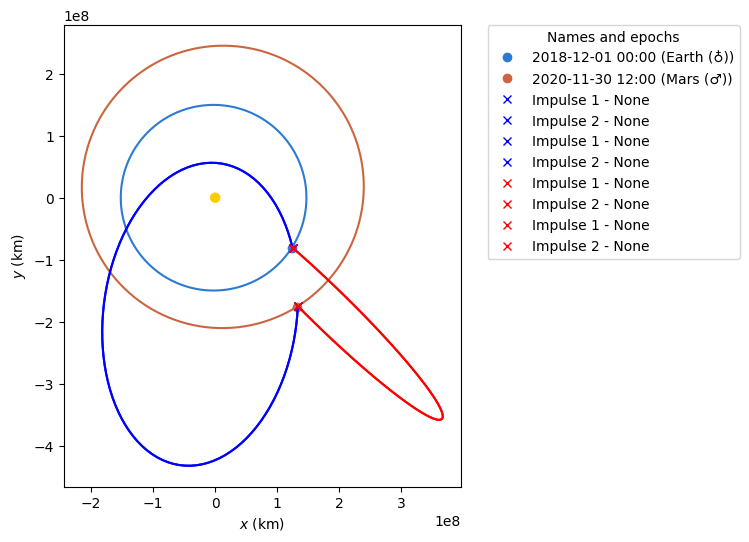

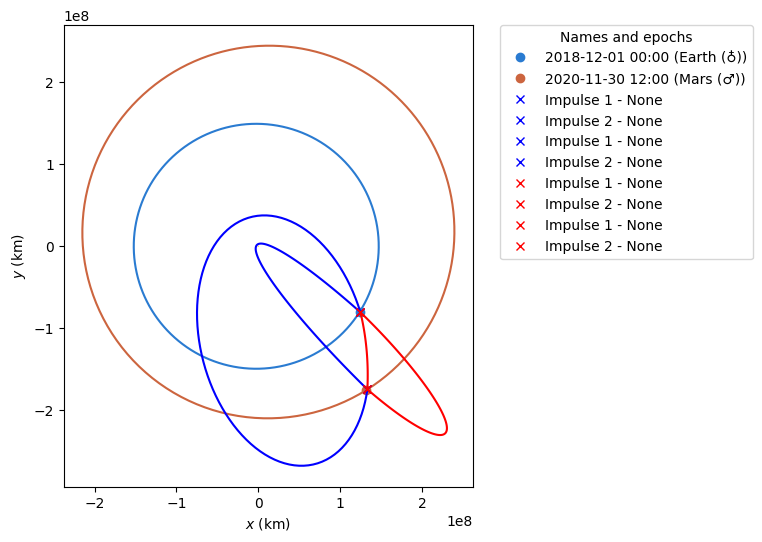

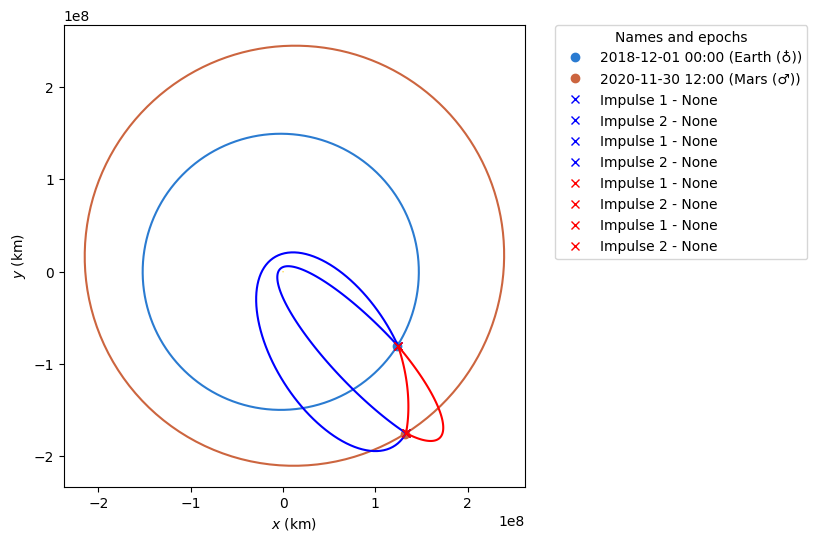

In [6]:
# Generate a grid of 3x1 plots

for ith_case, M in enumerate(range(3)):
    # Plot the orbits of the Earth and Mars

    op = OrbitPlotter()

    op.plot_body_orbit(Earth, EPOCH_DPT)
    op.plot_body_orbit(Mars, EPOCH_ARR)

    for ss, colorstyle in zip(
        lambert_solution_orbits(earth_departure, mars_arrival, M=M),
        colors_and_styles,
    ):
        ss_plot_traj = op.plot_maneuver(
            earth_departure, ss, color=colorstyle[0]
        )

plt.show()